In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# --------------------------------------------
# 1. Функции для загрузки и анализа
# --------------------------------------------

def load_series(filename, date_col='Month', val_col='Count', parse_dates=True):
    """
    Загружает CSV из папки 'Series' и возвращает Series с индексом-датой.
    Для Dow Jones (parse_dates=False) индекс остаётся строковым.
    """
    df = pd.read_csv(f'Series/{filename}')
    if parse_dates and date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col])
        df = df.set_index(date_col)
    else:
        df = df.set_index(date_col)
    return df[val_col]

def check_stationarity(series, title='', print_results=True):
    """Выполняет тест ADF и печатает результат."""
    s = series.dropna()
    if len(s) < 3:
        print(f'Ряд {title} слишком короткий для ADF')
        return False
    result = adfuller(s, autolag='AIC')
    if print_results:
        print(f'ADF Statistic for {title}: {result[0]:.4f}')
        print(f'p-value: {result[1]:.4f}')
        print('Critical values:')
        for key, value in result[4].items():
            print(f'\t{key}: {value:.4f}')
        if result[1] <= 0.05:
            print('=> Стационарен (отвергаем H0)')
        else:
            print('=> НЕ стационарен (принимаем H0)')
    return result[1] <= 0.05

def plot_series(series, title='', acf=True, pacf=True, max_lags=40):
    """
    Строит график ряда, ACF и PACF.
    Число лагов автоматически ограничивается 50% длины ряда.
    """
    s = series.dropna()
    n = len(s)
    lags = min(max_lags, n // 2 - 1) if n > 2 else 1
    if lags < 1:
        lags = 1
    fig, axes = plt.subplots(1, 3 if acf and pacf else 2, figsize=(15, 4))
    axes[0].plot(s)
    axes[0].set_title(title)
    if acf:
        plot_acf(s, ax=axes[1], lags=lags)
    if pacf:
        plot_pacf(s, ax=axes[2], lags=lags)
    plt.tight_layout()
    plt.show()

1. Ежемесячные продажи компании X

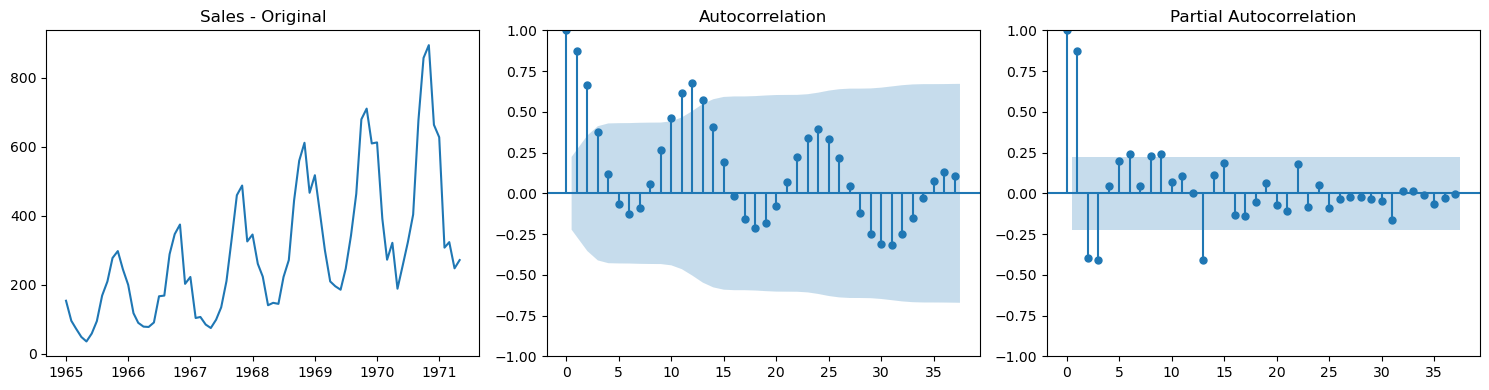

ADF Statistic for Original Sales: 0.6547
p-value: 0.9889
Critical values:
	1%: -3.5369
	5%: -2.9079
	10%: -2.5915
=> НЕ стационарен (принимаем H0)


np.False_

In [8]:
sales = load_series('monthly-sales-of-company-x-jan-6.csv')
plot_series(sales, 'Sales - Original')
check_stationarity(sales, 'Original Sales')


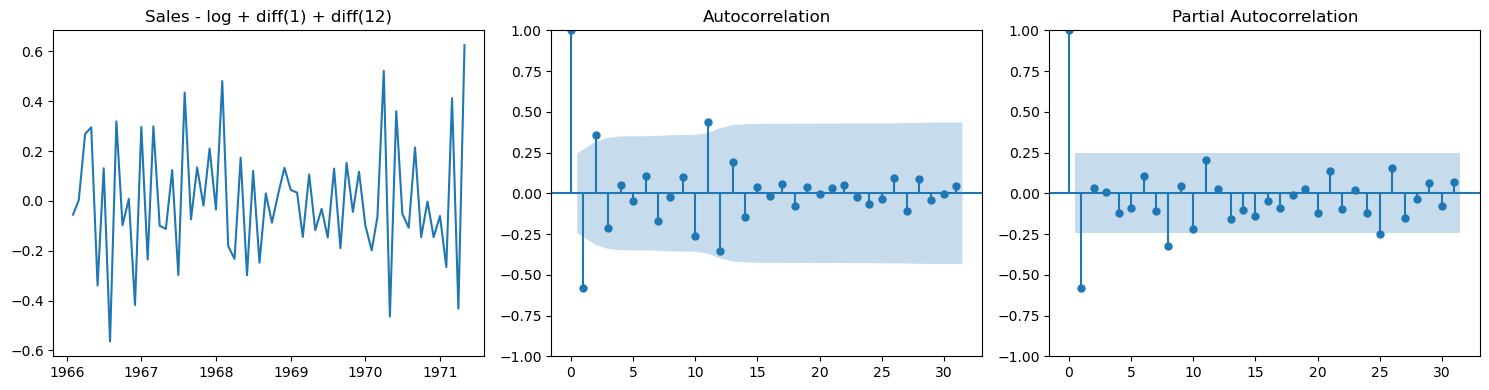

ADF Statistic for Transformed Sales: -2.3160
p-value: 0.1668
Critical values:
	1%: -3.5602
	5%: -2.9179
	10%: -2.5968
=> НЕ стационарен (принимаем H0)


np.False_

In [9]:
# Преобразование: логарифм + diff(1) + diff(12)
sales_log = np.log(sales)
sales_log_diff = sales_log.diff().dropna()
sales_log_diff_seasonal = sales_log_diff.diff(12).dropna()
plot_series(sales_log_diff_seasonal, 'Sales - log + diff(1) + diff(12)')
check_stationarity(sales_log_diff_seasonal, 'Transformed Sales')

2. Ограбления в Бостоне

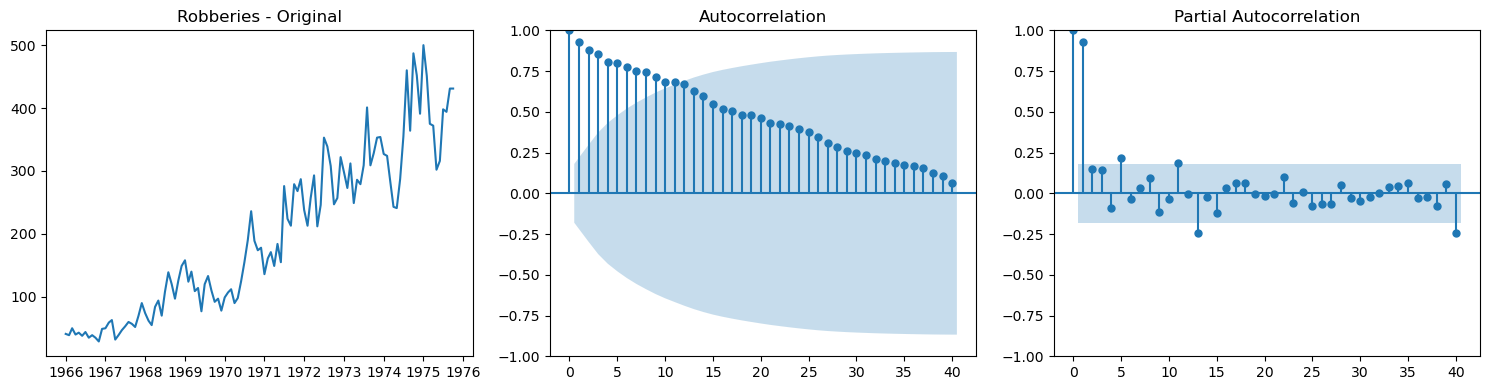

ADF Statistic for Original Robberies: 1.0011
p-value: 0.9943
Critical values:
	1%: -3.4936
	5%: -2.8892
	10%: -2.5815
=> НЕ стационарен (принимаем H0)


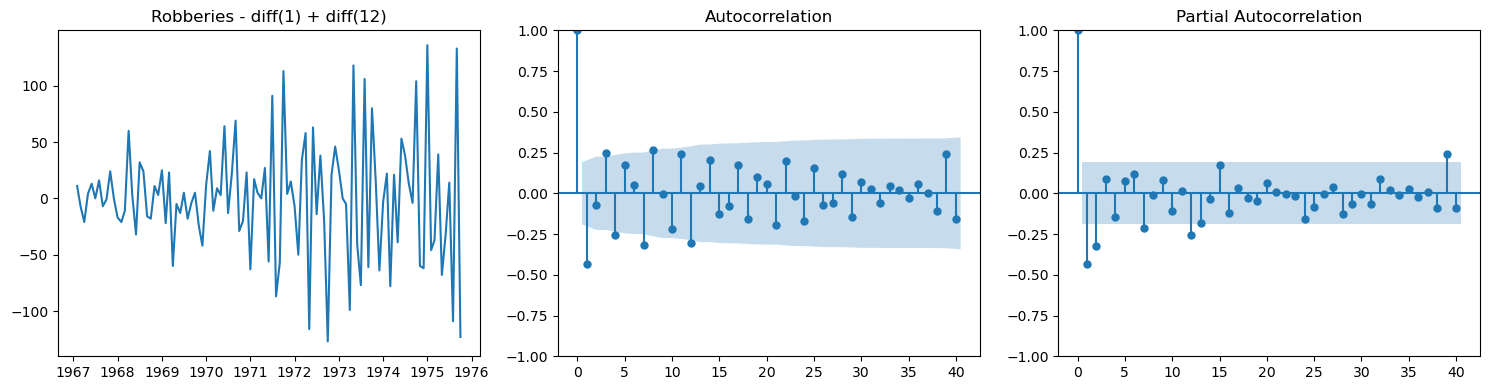

ADF Statistic for Transformed Robberies: -4.6160
p-value: 0.0001
Critical values:
	1%: -3.5035
	5%: -2.8935
	10%: -2.5838
=> Стационарен (отвергаем H0)


np.True_

In [10]:

robberies = load_series('monthly-boston-armed-robberies-j.csv')
plot_series(robberies, 'Robberies - Original')
check_stationarity(robberies, 'Original Robberies')

robberies_diff = robberies.diff().dropna()
robberies_diff_seasonal = robberies_diff.diff(12).dropna()
plot_series(robberies_diff_seasonal, 'Robberies - diff(1) + diff(12)')
check_stationarity(robberies_diff_seasonal, 'Transformed Robberies')

3. Авиапассажиры

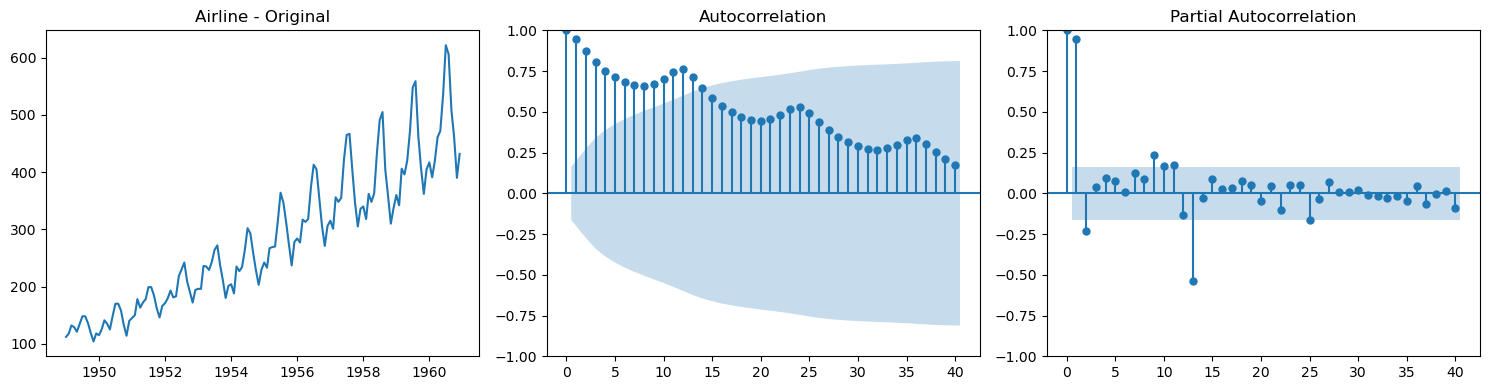

ADF Statistic for Original Airline: 0.8154
p-value: 0.9919
Critical values:
	1%: -3.4817
	5%: -2.8840
	10%: -2.5788
=> НЕ стационарен (принимаем H0)


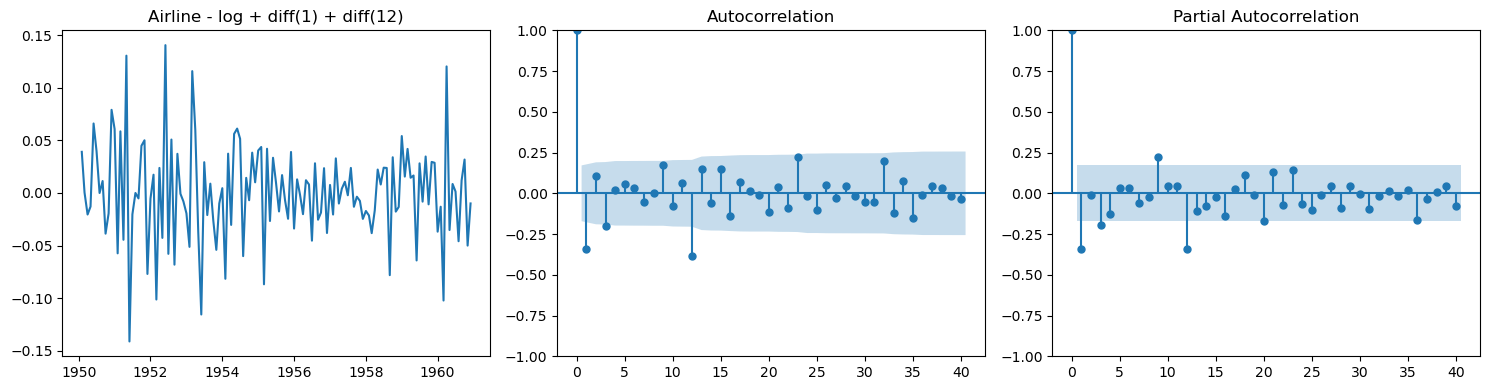

ADF Statistic for Transformed Airline: -4.4433
p-value: 0.0002
Critical values:
	1%: -3.4870
	5%: -2.8864
	10%: -2.5800
=> Стационарен (отвергаем H0)


np.True_

In [11]:
air = load_series('international-airline-passengers.csv')
plot_series(air, 'Airline - Original')
check_stationarity(air, 'Original Airline')

air_log = np.log(air)
air_log_diff = air_log.diff().dropna()
air_log_diff_seasonal = air_log_diff.diff(12).dropna()
plot_series(air_log_diff_seasonal, 'Airline - log + diff(1) + diff(12)')
check_stationarity(air_log_diff_seasonal, 'Transformed Airline')

4. Температура

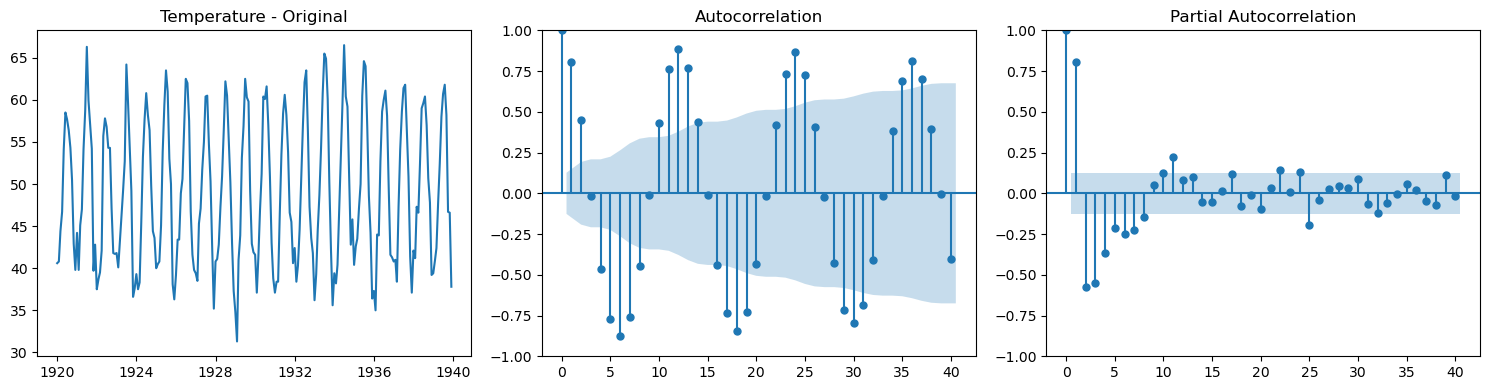

ADF Statistic for Original Temperature: -3.2555
p-value: 0.0170
Critical values:
	1%: -3.4598
	5%: -2.8745
	10%: -2.5737
=> Стационарен (отвергаем H0)


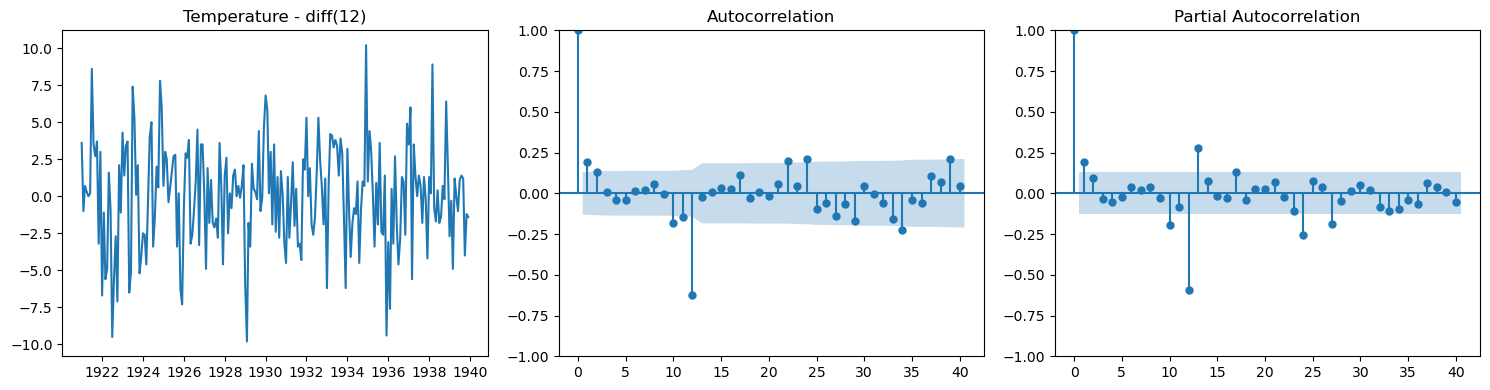

ADF Statistic for Transformed Temperature: -6.0725
p-value: 0.0000
Critical values:
	1%: -3.4611
	5%: -2.8751
	10%: -2.5740
=> Стационарен (отвергаем H0)


np.True_

In [13]:
temp = load_series('mean-monthly-air-temperature-deg.csv', val_col='Deg')
plot_series(temp, 'Temperature - Original')
check_stationarity(temp, 'Original Temperature')

temp_seasonal = temp.diff(12).dropna()
plot_series(temp_seasonal, 'Temperature - diff(12)')
check_stationarity(temp_seasonal, 'Transformed Temperature')



5. Dow Jones (недельный) – специальная обработка индекса

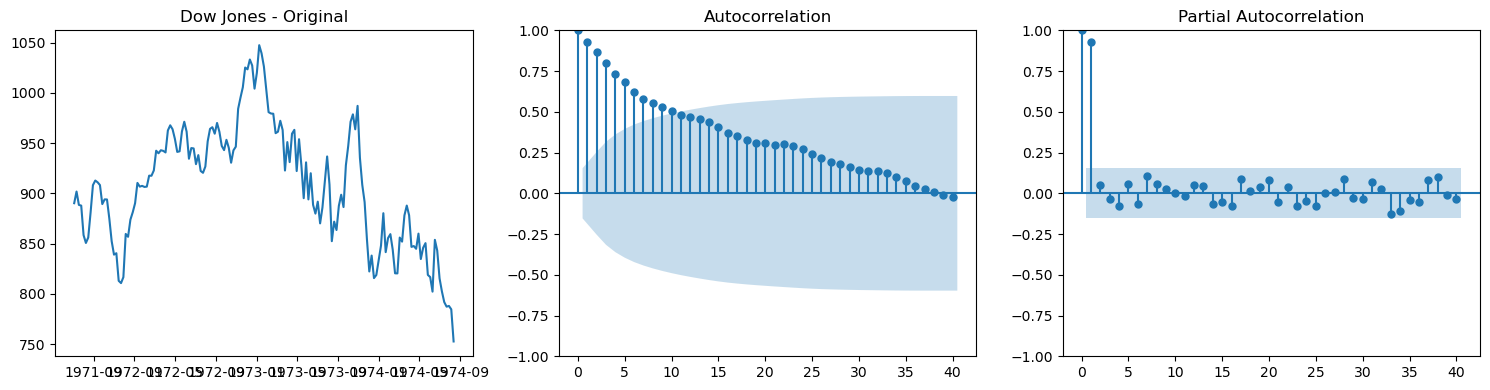

ADF Statistic for Original Dow: -1.3146
p-value: 0.6225
Critical values:
	1%: -3.4716
	5%: -2.8797
	10%: -2.5764
=> НЕ стационарен (принимаем H0)


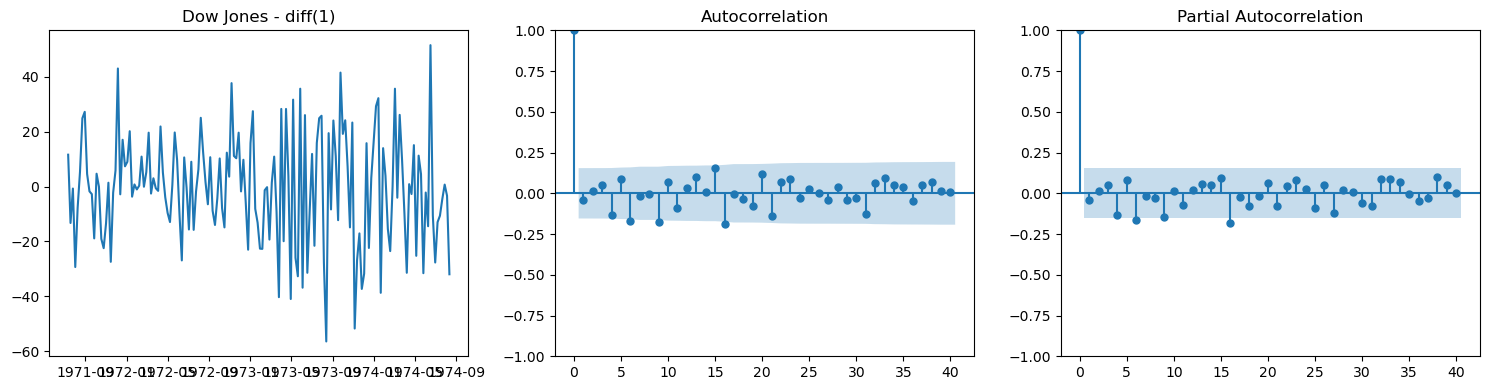

ADF Statistic for Transformed Dow: -13.0252
p-value: 0.0000
Critical values:
	1%: -3.4719
	5%: -2.8798
	10%: -2.5765
=> Стационарен (отвергаем H0)


np.True_

In [14]:

dow_raw = load_series('weekly-closings-of-the-dowjones-.csv', 
                      date_col='Week', val_col='Close', parse_dates=False)
# Преобразуем строки вида "1971-W27" в дату (первый день недели)
dow_index = pd.to_datetime(dow_raw.index + '-1', format='%Y-W%W-%w')
dow = pd.Series(dow_raw.values, index=dow_index, name='Close')
dow = dow.sort_index()
plot_series(dow, 'Dow Jones - Original')
check_stationarity(dow, 'Original Dow')

dow_diff = dow.diff().dropna()
plot_series(dow_diff, 'Dow Jones - diff(1)')
check_stationarity(dow_diff, 'Transformed Dow')

6. Ежедневные рождения (девочки)

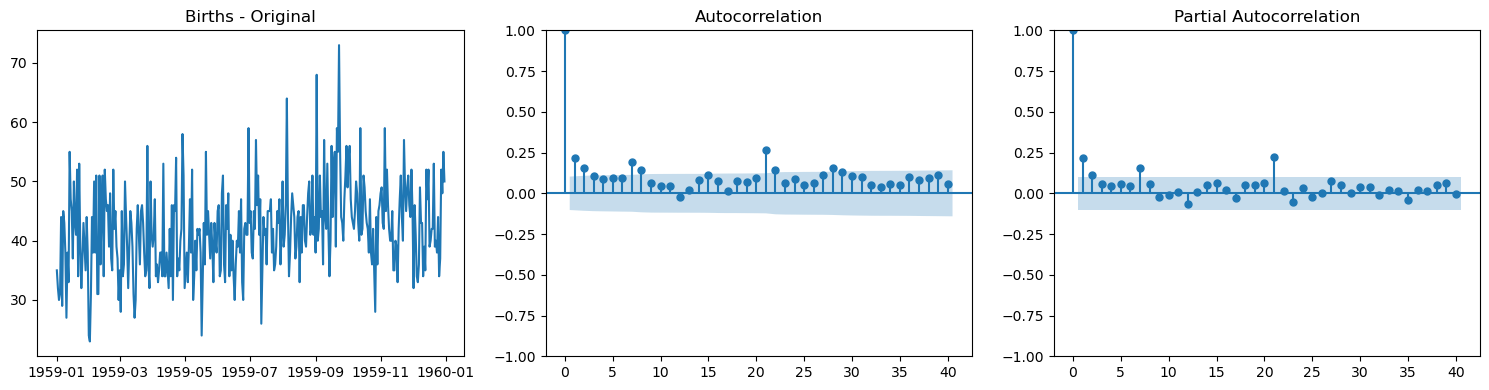

ADF Statistic for Original Births: -4.8083
p-value: 0.0001
Critical values:
	1%: -3.4487
	5%: -2.8696
	10%: -2.5711
=> Стационарен (отвергаем H0)


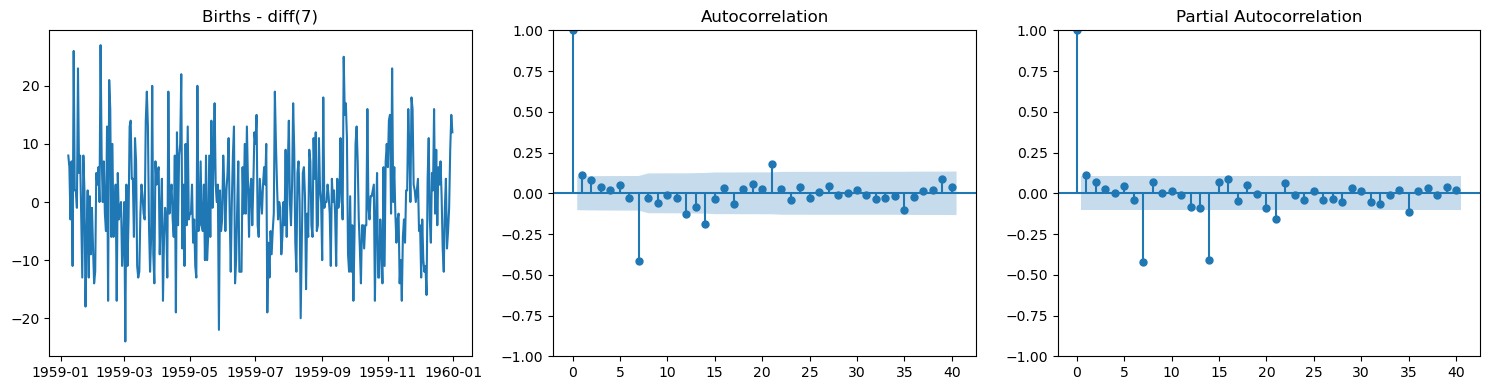

ADF Statistic for Transformed Births: -8.3168
p-value: 0.0000
Critical values:
	1%: -3.4496
	5%: -2.8700
	10%: -2.5713
=> Стационарен (отвергаем H0)


np.True_

In [15]:
births = load_series('daily-total-female-births-in-cal.csv', date_col='Date', val_col='Count')
plot_series(births, 'Births - Original')
check_stationarity(births, 'Original Births')

births_seasonal = births.diff(7).dropna()
plot_series(births_seasonal, 'Births - diff(7)')
check_stationarity(births_seasonal, 'Transformed Births')

Итоговая таблица преобразований

In [16]:
summary = pd.DataFrame({
    'Ряд': ['Продажи', 'Ограбления', 'Авиапассажиры', 'Температура', 'Dow Jones', 'Рождаемость'],
    'Преобразование': ['log + diff(1) + diff(12)', 'diff(1) + diff(12)', 
                       'log + diff(1) + diff(12)', 'diff(12)', 'diff(1)', 'diff(7)'],
    'Стационарен?': ['Да'] * 6
})
print('\n=== ИТОГОВАЯ ТАБЛИЦА ===')
print(summary.to_string(index=False))


=== ИТОГОВАЯ ТАБЛИЦА ===
          Ряд           Преобразование Стационарен?
      Продажи log + diff(1) + diff(12)           Да
   Ограбления       diff(1) + diff(12)           Да
Авиапассажиры log + diff(1) + diff(12)           Да
  Температура                 diff(12)           Да
    Dow Jones                  diff(1)           Да
  Рождаемость                  diff(7)           Да
